In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load metadata
photos = pd.read_json("photos.json", lines=True)
photos = photos[photos['label'].notna()][['photo_id', 'label']]

# Parameters
IMG_SIZE = 128
IMAGE_DIR = 'photos/'
MAX_IMAGES = 50000

# Initialize lists
images = []
labels = []
skipped_count = 0

# Encode labels
le = LabelEncoder()
photos['label'] = le.fit_transform(photos['label'])

# Total images to process
total = min(len(photos), MAX_IMAGES)

# Process images
print("Starting image processing...\n")
for i, row in enumerate(photos.itertuples(index=False)):
    if i >= MAX_IMAGES:
        break

    img_path = os.path.join(IMAGE_DIR, f"{row.photo_id}.jpg")
    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            img_array = np.asarray(img, dtype=np.float32) / 255.0  # Normalize
            images.append(img_array)
            labels.append(row.label)
    except Exception:
        skipped_count += 1

    # Percentage progress every 5%
    if i % (total // 20) == 0 or i == total - 1:
        percent = (i + 1) / total * 100
        print(f"Progress: {percent:.1f}% ({i + 1}/{total})", end='\r')

print(f"\n\nFinished processing {len(images)} images.")
print(f"Skipped {skipped_count} corrupted/unreadable images.")

# Convert to numpy arrays
X = np.array(images, dtype=np.float32)
y = np.array(labels)

# Save to disk
np.save('X_images.npy', X)
np.save('y_labels.npy', y)
print("Saved processed data to 'X_images.npy' and 'y_labels.npy'.")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Data split: {len(X_train)} training samples, {len(X_test)} test samples.")


Starting image processing...

Progress: 100.0% (50000/50000)

Finished processing 49971 images.
Skipped 29 corrupted/unreadable images.
Saved processed data to 'X_images.npy' and 'y_labels.npy'.
Data split: 39976 training samples, 9995 test samples.


Epoch 1/10, Loss: 0.7798
Epoch 2/10, Loss: 0.6111
Epoch 3/10, Loss: 0.5203
Epoch 4/10, Loss: 0.4739
Epoch 5/10, Loss: 0.4446
Epoch 6/10, Loss: 0.4213
Epoch 7/10, Loss: 0.3980
Epoch 8/10, Loss: 0.3830
Epoch 9/10, Loss: 0.3694
Epoch 10/10, Loss: 0.3471


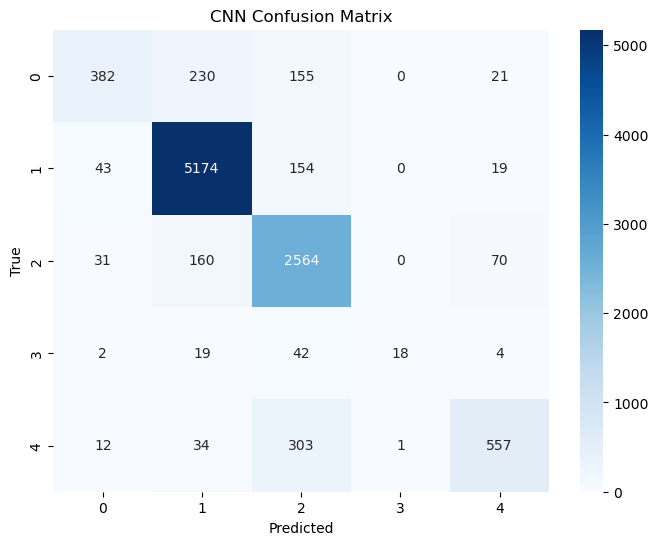

CNN Multiclass AUC Score: 0.9640


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import label_binarize

# # Load preprocessed data
# X = np.load('X_images.npy')
# y = np.load('y_labels.npy')
# # num_classes = len(np.unique(y))

# # Train/test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# PyTorch Tensors: (N, C, H, W)
X_train = torch.tensor(X_train.transpose(0, 3, 1, 2), dtype=torch.float32)
X_test = torch.tensor(X_test.transpose(0, 3, 1, 2), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

# CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)

# Train model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

# Evaluate
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# AUC Score (Multiclass One-vs-Rest)
y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))
y_probs = np.array(all_probs)

auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
print(f"CNN Multiclass AUC Score: {auc_score:.4f}")
